# Fig: balls

project = ```iP-VAE```, host = ```any```, device = ```any```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'results_2025-03')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(624, 0)

## BALLS dataset

In [4]:
files = [f for f in os.listdir(results_dir) if 'BALLS' in f]
files = sorted(files, key=alphanum_sort_key)

len(files)

225

In [5]:
results_dir = pjoin(tmp_dir, 'results_2025-04')
files = [
    f for f in os.listdir(results_dir)
    if 'BALLS64' in f
    # if 'BALLS64_t-32_b-96_k-[96]' in f
]
files = sorted(files, key=alphanum_sort_key)
# print(files)

len(files)

124

In [6]:
info_keys = [
    'dataset', 'type', 'latent_act', 'str_model', 'n_params',
    't_train', 'beta_outer', 'n_latents', 'lr', 'clamp_u', 'seed', 'timestamp',
]

df_oos = collections.defaultdict(list)

for f in tqdm(files):
    is_amortized = 'amort' in f
    try:
        load = np.load(
            pjoin(results_dir, f),
            allow_pickle=True,
        ).item()
    except EOFError:
        print(f"EOFError:\n{f}")
        continue

    info, results = load['info'], load['results']
    if isinstance(info['n_latents'], list):
        info['n_latents'] = info['n_latents'][0]
    input_size = dataset_dims(info['dataset'])
    total_dims = np.prod(input_size)

    for split in ['vld', 'tst']:
        for t_idx, t in enumerate(list(results['r2_zg']['trn'])):
            # info
            for k in info_keys:
                df_oos[k].append(info.get(k, None))
            df_oos['amort'].append(is_amortized)
            # results
            vals = {
                'split': split,
                'time': t,
                'untangle_r2': results['r2_zg'][split][t].mean(),
                'untangle_r2_a': results['r2_zg'][split][t][0],
                'untangle_r2_b': results['r2_zg'][split][t][1],
                'untangle_corr': results['corr_zg'][split][t].mean(),
                'untangle_corr_a': results['corr_zg'][split][t][0],
                'untangle_corr_b': results['corr_zg'][split][t][1],
                'recon_r2': results['results_xtract'][split]['r2'][t - 1],
                'recon_mse': results['results_xtract'][split]['mse'][t - 1],
                'recon_mse_perdim': results['results_xtract'][split]['mse'][t - 1] / total_dims * 1e3,
                '%-zeros': np.mean(results['results_xtract'][split]['samples'][:, t_idx, :] == 0.0),
            }
            for k, v in vals.items():
                df_oos[k].append(v)

df_oos = pd.DataFrame(df_oos)
df_oos.shape

100%|█████████████████████████████████████████| 124/124 [02:40<00:00,  1.29s/it]


(5208, 25)

In [7]:
df_oos_pois = df_oos.loc[
    (df_oos['str_model'] == 'poisson') &
    (df_oos['split'] == 'tst') &
    (df_oos['time'] == 1000) &
    (df_oos['untangle_r2'] > 0.1)
]
df_oos_pois = df_oos_pois.drop(columns=[
    'dataset', 'type', 'latent_act',
    'str_model', 'n_params', 'amort',
])
df_oos_pois = df_oos_pois.sort_values(by='untangle_r2', ascending=False)

df_oos_pois.shape

(49, 19)

In [8]:
df_oos_pois

,t_train,beta_outer,n_latents,lr,clamp_u,seed,timestamp,split,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,recon_mse_perdim,%-zeros
3905,32.0,96.0,96,0.0005,10.0,103,"2025_04_28,09:10",tst,1000,0.991616,0.992047,0.991184,0.996061,0.996030,0.996092,0.991991,1.825771,0.445745,0.785185
4115,32.0,96.0,96,0.0005,10.0,108,"2025_04_27,18:27",tst,1000,0.991320,0.991668,0.990971,0.995813,0.995907,0.995720,0.991584,1.917611,0.468167,0.773591
3485,32.0,96.0,96,0.0005,10.0,77,"2025_04_28,02:07",tst,1000,0.991096,0.991406,0.990787,0.995610,0.995829,0.995391,0.991261,1.992770,0.486516,0.786497
4283,32.0,96.0,96,0.0005,10.0,113,"2025_04_28,23:47",tst,1000,0.991080,0.991008,0.991152,0.995710,0.995732,0.995688,0.991173,2.012267,0.491276,0.757927
3359,32.0,96.0,96,0.0005,10.0,74,"2025_04_27,18:19",tst,1000,0.990750,0.990117,0.991383,0.995865,0.995674,0.996056,0.991645,1.904577,0.464985,0.762169
4073,32.0,96.0,96,0.0005,10.0,107,"2025_04_29,14:26",tst,1000,0.989536,0.990835,0.988237,0.995726,0.995693,0.995758,0.991436,1.952691,0.476731,0.772021
3947,32.0,96.0,96,0.0005,10.0,104,"2025_04_29,00:09",tst,1000,0.989509,0.987825,0.991193,0.995194,0.994491,0.995897,0.991482,1.940762,0.473819,0.778698
3275,32.0,96.0,96,0.0005,10.0,72,"2025_04_27,18:19",tst,1000,0.989492,0.987173,0.991810,0.995335,0.994658,0.996011,0.991786,1.872220,0.457085,0.765830
3527,32.0,96.0,96,0.0005,10.0,78,"2025_04_28,09:56",tst,1000,0.989374,0.990980,0.987767,0.995737,0.995864,0.995610,0.992034,1.815882,0.443331,0.790828
4241,32.0,96.0,96,0.0005,10.0,112,"2025_04_28,10:48",tst,1000,0.989012,0.991051,0.986974,0.995690,0.995804,0.995575,0.991696,1.891542,0.461802,0.771126


In [9]:
df_oos_gaus = df_oos.loc[
    (df_oos['str_model'] == 'gaussian') &
    (df_oos['split'] == 'tst') &
    (df_oos['time'] == 1000) &
    (df_oos['untangle_r2'] > 0.1)
]
df_oos_gaus = df_oos_gaus.drop(columns=[
    'dataset', 'type', 'latent_act',
    'str_model', 'n_params', 'amort',
])
df_oos_gaus = df_oos_gaus.sort_values(by='untangle_r2', ascending=False)

df_oos_gaus.shape

(19, 19)

In [10]:
df_oos_gaus

,t_train,beta_outer,n_latents,lr,clamp_u,seed,timestamp,split,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,recon_mse_perdim,%-zeros
1217,32.0,8.0,96,0.0005,"[7.0, 2.0]",13,"2025_05_01,05:39",tst,1000,0.982245,0.982010,0.982479,0.991359,0.991409,0.991310,0.981404,4.241330,1.035481,0.0
1385,32.0,8.0,96,0.0005,"[7.0, 2.0]",11,"2025_05_01,00:04",tst,1000,0.980193,0.979782,0.980603,0.990978,0.990686,0.991270,0.980574,4.428319,1.081133,0.0
1343,32.0,8.0,96,0.0005,"[7.0, 2.0]",10,"2025_05_01,00:04",tst,1000,0.978141,0.979376,0.976906,0.990634,0.990343,0.990925,0.979820,4.592588,1.121237,0.0
1259,32.0,8.0,96,0.0005,"[7.0, 2.0]",14,"2025_05_01,00:07",tst,1000,0.978120,0.978049,0.978190,0.989843,0.990090,0.989596,0.978345,4.934747,1.204772,0.0
1301,32.0,8.0,96,0.0005,"[7.0, 2.0]",15,"2025_05_01,05:40",tst,1000,0.977918,0.980477,0.975359,0.990767,0.990829,0.990705,0.980762,4.385174,1.070599,0.0
1091,32.0,1.0,96,0.0005,"[7.0, 2.0]",18,"2025_05_01,11:46",tst,1000,0.973513,0.973457,0.973568,0.986978,0.986897,0.987059,0.982500,3.984327,0.972736,0.0
923,32.0,1.0,96,0.0005,"[7.0, 2.0]",13,"2025_05_01,11:46",tst,1000,0.972434,0.971401,0.973467,0.987290,0.987399,0.987180,0.981657,4.185799,1.021923,0.0
1133,32.0,1.0,96,0.0005,"[7.0, 2.0]",19,"2025_05_01,11:46",tst,1000,0.972320,0.972429,0.972210,0.986740,0.986237,0.987243,0.980537,4.441170,1.084270,0.0
1175,32.0,8.0,96,0.0005,"[7.0, 2.0]",12,"2025_05_01,00:07",tst,1000,0.971241,0.970546,0.971935,0.989256,0.988973,0.989540,0.979782,4.602654,1.123695,0.0
881,32.0,1.0,96,0.0005,"[7.0, 2.0]",11,"2025_05_01,11:46",tst,1000,0.969512,0.965965,0.973060,0.986233,0.985499,0.986967,0.981723,4.161704,1.016041,0.0


In [11]:
df_oos_gausrelu = df_oos.loc[
    (df_oos['str_model'] == 'gaussian+relu') &
    (df_oos['split'] == 'tst') &
    (df_oos['time'] == 1000) # &
    # (df_oos['untangle_r2'] > 0.1)
]
df_oos_gausrelu = df_oos_gausrelu.drop(columns=[
    'dataset', 'type', 'latent_act',
    'str_model', 'n_params', 'amort',
])
df_oos_gausrelu = df_oos_gausrelu.sort_values(
    by='untangle_r2', ascending=False)

df_oos_gausrelu.shape

(19, 19)

In [12]:
df_oos_gausrelu

,t_train,beta_outer,n_latents,lr,clamp_u,seed,timestamp,split,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,recon_mse_perdim,%-zeros
125,8.0,1.0,96,0.0005,"[7.0, 2.0]",0,"2025_05_01,13:08",tst,1000,0.840283,0.831613,0.848952,0.957133,0.954415,0.959850,0.858058,32.346119,7.897002,0.676780
167,8.0,1.0,96,0.0005,"[7.0, 2.0]",1,"2025_05_01,13:08",tst,1000,0.819983,0.804429,0.835537,0.954596,0.952548,0.956644,0.862406,31.354355,7.654872,0.677198
41,4.0,1.0,96,0.0005,"[7.0, 2.0]",0,"2025_05_01,13:08",tst,1000,0.635848,0.648067,0.623629,0.861260,0.868291,0.854229,0.886022,26.010532,6.350228,0.750254
83,4.0,1.0,96,0.0005,"[7.0, 2.0]",1,"2025_05_01,13:08",tst,1000,0.385051,0.427782,0.342320,0.832557,0.809162,0.855951,0.888427,25.469894,6.218236,0.747758
713,NaN,NaN,96,0.0005,None,12,"2025_04_18,06:24",tst,1000,-0.042514,-0.091498,0.006471,0.650359,0.648431,0.652287,0.482643,117.776329,28.753987,0.853752
797,NaN,NaN,96,0.0005,None,14,"2025_04_17,23:05",tst,1000,-0.286315,-0.065749,-0.506880,0.619520,0.591421,0.647619,0.326179,153.292786,37.424996,0.881101
629,NaN,NaN,96,0.0005,None,10,"2025_04_17,23:05",tst,1000,-0.328561,-0.115059,-0.542063,0.647127,0.754948,0.539307,0.490262,115.912872,28.299041,0.850127
755,NaN,NaN,96,0.0005,None,13,"2025_04_17,23:05",tst,1000,-0.564580,-0.168055,-0.961106,0.654489,0.700963,0.608015,0.222785,177.550934,43.347396,0.885281
671,NaN,NaN,96,0.0005,None,11,"2025_04_17,23:05",tst,1000,-0.649567,-0.260414,-1.038719,0.514032,0.559126,0.468938,0.279448,164.176865,40.082242,0.884819
251,16.0,1.0,96,0.0005,"[7.0, 2.0]",1,"2025_05_01,13:08",tst,1000,-4.423757,-4.295012,-4.552501,0.220445,0.231394,0.209496,0.066921,213.457520,52.113652,0.973540


In [20]:
_df = df_oos_gausrelu.loc[df_oos_gausrelu['beta_outer'] > 0]
_df = _df.sort_values(by='t_train')
_df

,t_train,beta_outer,n_latents,lr,clamp_u,seed,timestamp,split,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,recon_mse_perdim,%-zeros
83,4.0,1.0,96,0.0005,"[7.0, 2.0]",1,"2025_05_01,13:08",tst,1000,0.385051,0.427782,0.342320,0.832557,0.809162,0.855951,0.888427,25.469894,6.218236,0.747758
41,4.0,1.0,96,0.0005,"[7.0, 2.0]",0,"2025_05_01,13:08",tst,1000,0.635848,0.648067,0.623629,0.861260,0.868291,0.854229,0.886022,26.010532,6.350228,0.750254
167,8.0,1.0,96,0.0005,"[7.0, 2.0]",1,"2025_05_01,13:08",tst,1000,0.819983,0.804429,0.835537,0.954596,0.952548,0.956644,0.862406,31.354355,7.654872,0.677198
125,8.0,1.0,96,0.0005,"[7.0, 2.0]",0,"2025_05_01,13:08",tst,1000,0.840283,0.831613,0.848952,0.957133,0.954415,0.959850,0.858058,32.346119,7.897002,0.676780
251,16.0,1.0,96,0.0005,"[7.0, 2.0]",1,"2025_05_01,13:08",tst,1000,-4.423757,-4.295012,-4.552501,0.220445,0.231394,0.209496,0.066921,213.457520,52.113652,0.973540
209,16.0,1.0,96,0.0005,"[7.0, 2.0]",0,"2025_05_01,13:08",tst,1000,-4.494904,-4.473122,-4.516685,0.241363,0.268041,0.214685,0.039590,219.550507,53.601198,0.975795
377,32.0,8.0,96,0.0005,"[7.0, 2.0]",14,"2025_05_01,00:07",tst,1000,-4.473975,-4.188724,-4.759227,0.173716,0.266831,0.080601,-0.055647,241.602493,58.984984,0.978045
335,32.0,8.0,96,0.0005,"[7.0, 2.0]",13,"2025_05_01,06:06",tst,1000,-4.441239,-4.767300,-4.115178,0.228458,0.300045,0.156871,-0.044589,239.088181,58.371138,0.977971
503,32.0,8.0,96,0.0005,"[7.0, 2.0]",11,"2025_05_01,00:04",tst,1000,-4.479419,-4.771321,-4.187517,0.201738,0.121229,0.282246,-0.037248,237.351974,57.947259,0.977391
461,32.0,8.0,96,0.0005,"[7.0, 2.0]",10,"2025_05_01,00:04",tst,1000,-4.710678,-4.991284,-4.430072,0.066531,0.050885,0.082177,-0.046268,239.287079,58.419697,0.977482


In [13]:
final_selection = {
    'poisson': (32, 96.0),
    'gaussian': (32, 8.0),
    'gaussian+relu': (32, 8.0),
}

In [25]:
df_selected = []
for str_model, (t_train, beta) in final_selection.items():
    _df = df_oos.loc[
        (df_oos['str_model'] == str_model) &
        (df_oos['t_train'] == t_train) &
        (df_oos['beta_outer'] == beta) &
        (df_oos['n_latents'] == 96) &
        (df_oos['split'] == 'tst') &
        (df_oos['lr'] == 0.0005) &
        (df_oos['time'] == 1000)
    ]
    if str_model != 'gaussian+relu':
        _df = _df.loc[_df['untangle_r2'] > 0.1]
    _df = _df.drop(columns=[
        'dataset', 'type', 'split', 'timestamp',
        'latent_act', 'n_params', 'recon_mse_perdim',
    ])
    df_selected.append(_df)

df_selected = pd.concat(df_selected)
df_selected = df_selected.sort_values(
    by='untangle_r2', ascending=False)
df_selected.shape

(47, 18)

In [26]:
df_selected

,str_model,t_train,beta_outer,n_latents,lr,clamp_u,seed,amort,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,%-zeros
3905,poisson,32.0,96.0,96,0.0005,10.0,103,False,1000,0.991616,0.992047,0.991184,0.996061,0.996030,0.996092,0.991991,1.825771,0.785185
4115,poisson,32.0,96.0,96,0.0005,10.0,108,False,1000,0.991320,0.991668,0.990971,0.995813,0.995907,0.995720,0.991584,1.917611,0.773591
3485,poisson,32.0,96.0,96,0.0005,10.0,77,False,1000,0.991096,0.991406,0.990787,0.995610,0.995829,0.995391,0.991261,1.992770,0.786497
4283,poisson,32.0,96.0,96,0.0005,10.0,113,False,1000,0.991080,0.991008,0.991152,0.995710,0.995732,0.995688,0.991173,2.012267,0.757927
3359,poisson,32.0,96.0,96,0.0005,10.0,74,False,1000,0.990750,0.990117,0.991383,0.995865,0.995674,0.996056,0.991645,1.904577,0.762169
4073,poisson,32.0,96.0,96,0.0005,10.0,107,False,1000,0.989536,0.990835,0.988237,0.995726,0.995693,0.995758,0.991436,1.952691,0.772021
3947,poisson,32.0,96.0,96,0.0005,10.0,104,False,1000,0.989509,0.987825,0.991193,0.995194,0.994491,0.995897,0.991482,1.940762,0.778698
3275,poisson,32.0,96.0,96,0.0005,10.0,72,False,1000,0.989492,0.987173,0.991810,0.995335,0.994658,0.996011,0.991786,1.872220,0.765830
3527,poisson,32.0,96.0,96,0.0005,10.0,78,False,1000,0.989374,0.990980,0.987767,0.995737,0.995864,0.995610,0.992034,1.815882,0.790828
4241,poisson,32.0,96.0,96,0.0005,10.0,112,False,1000,0.989012,0.991051,0.986974,0.995690,0.995804,0.995575,0.991696,1.891542,0.771126


In [39]:
df_selected.groupby('str_model').mean(numeric_only=True)

,t_train,beta_outer,n_latents,lr,seed,amort,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,%-zeros
str_model,,,,,,,,,,,,,,,,
gaussian,32.0,8.0,96.0,0.0005,12.500000,0.0,1000.0,0.977976,0.978373,0.977579,0.990473,0.990388,0.990558,0.980114,4.530802,0.000000
gaussian+relu,32.0,8.0,96.0,0.0005,12.500000,0.0,1000.0,-4.639323,-4.746760,-4.531887,0.158798,0.176489,0.141107,-0.045598,239.216492,0.978187
poisson,32.0,96.0,96.0,0.0005,96.228571,0.0,1000.0,0.972401,0.971012,0.973789,0.990687,0.989387,0.991986,0.991065,2.036353,0.763385


In [32]:
collections.Counter(df_selected['str_model'])

Counter({'poisson': 35, 'gaussian': 6, 'gaussian+relu': 6})

In [35]:
sorted(df_selected.loc[df_selected['str_model'] == 'gaussian', 'seed'].unique())

[10, 11, 12, 13, 14, 15]

In [36]:
sorted(df_selected.loc[df_selected['str_model'] == 'gaussian+relu', 'seed'].unique())

[10, 11, 12, 13, 14, 15]

## Amort?

In [49]:
results_dir = pjoin(tmp_dir, 'results_2025-03')
files_march = sorted(os.listdir(results_dir), key=alphanum_sort_key)
files_amort = [
    f for f in files_march
    if 'amort' in f and 'BALLS64' in f
]
print(files_amort)

[
    'gaussian+relu-<conv+b|lin>-BALLS64-b-0.5_k-512-amort_chewie-1_(2025_03_20,03:26).npy',
    'gaussian+relu-<conv+b|lin>-BALLS64-b-1_k-512-amort_chewie-1_(2025_03_20,01:50).npy',
    'gaussian+relu-<conv+b|lin>-BALLS64-b-2_k-512-amort_chewie-1_(2025_03_20,20:02).npy',
    'gaussian+relu-<conv+b|lin>-BALLS64-b-5_k-512-amort_chewie-1_(2025_03_20,17:41).npy',
    'gaussian-<conv+b|lin>-BALLS64-b-0.5_k-512-amort_chewie-1_(2025_03_20,20:42).npy',
    'gaussian-<conv+b|lin>-BALLS64-b-1_k-512-amort_chewie-1_(2025_03_20,18:25).npy',
    'gaussian-<conv+b|lin>-BALLS64-b-2_k-512-amort_chewie-1_(2025_03_19,10:54).npy',
    'gaussian-<conv+b|lin>-BALLS64-b-5_k-512-amort_chewie-1_(2025_03_19,10:07).npy',
    'poisson-<conv+b|lin>-BALLS64-b-0.5_k-512-amort_chewie-1_(2025_03_19,11:33).npy',
    'poisson-<conv+b|lin>-BALLS64-b-1_k-512-amort_chewie-1_(2025_03_19,10:47).npy',
    'poisson-<conv+b|lin>-BALLS64-b-2_k-512-amort_chewie-1_(2025_03_20,04:53).npy',
    'poisson-<conv+b|lin>-BALLS64-b-5_k-512-amort_chewie-1_(2025_03_20,03:19).npy'
]

In [61]:
for f in tqdm(files_amort):
    is_amortized = 'amort' in f
    try:
        load = np.load(
            pjoin(results_dir, f),
            allow_pickle=True,
        ).item()
    except EOFError:
        print(f"EOFError:\n{f}")
        continue

    info, results = load['info'], load['results']
    if isinstance(info['n_latents'], list):
        info['n_latents'] = info['n_latents'][0]
    input_size = dataset_dims(info['dataset'])
    total_dims = np.prod(input_size)

    print(info, results['r2_zg']['tst'].mean(), results['r2'], '\n\n')

  0%|                                                    | 0/12 [00:00<?, ?it/s]

{
    'checkpoint': 1500,
    'timestamp': '2025_03_19,10:54',
    'seed': 1,
    'dataset': 'BALLS64',
    'type': 'gaussian',
    'latent_act': 'relu',
    'n_latents': 512,
    'str_model': 'gaussian+relu+amort',
    'archi': '<conv+b|lin>',
    'seq_len': 1,
    'kl_beta': 0.5,
    'n_params': 22276732,
    'n_iters_train': 90000
}
0.9884683009663888 0.9835091829299927

{
    'checkpoint': 1500,
    'timestamp': '2025_03_19,10:07',
    'seed': 1,
    'dataset': 'BALLS64',
    'type': 'gaussian',
    'latent_act': 'relu',
    'n_latents': 512,
    'str_model': 'gaussian+relu+amort',
    'archi': '<conv+b|lin>',
    'seq_len': 1,
    'kl_beta': 1.0,
    'n_params': 22276732,
    'n_iters_train': 90000
}
0.9963434560444837 0.9706366062164307

 17%|███████▎                                    | 2/12 [00:00<00:00, 19.66it/s]

{
    'checkpoint': 1500,
    'timestamp': '2025_03_20,03:26',
    'seed': 1,
    'dataset': 'BALLS64',
    'type': 'gaussian',
    'latent_act': 'relu',
    'n_latents': 512,
    'str_model': 'gaussian+relu+amort',
    'archi': '<conv+b|lin>',
    'seq_len': 1,
    'kl_beta': 2.0,
    'n_params': 22276732,
    'n_iters_train': 90000
}
0.9918140276137528 0.9493956565856934

...

{
    'checkpoint': 1500,
    'timestamp': '2025_03_18,18:22',
    'seed': 1,
    'dataset': 'BALLS64',
    'type': 'poisson',
    'latent_act': None,
    'n_latents': 512,
    'str_model': 'poisson+amort',
    'archi': '<conv+b|lin>',
    'seq_len': 1,
    'kl_beta': 1.0,
    'n_params': 22014588,
    'n_iters_train': 90000
}
0.4352659091827346 0.8657515645027161

 83%|███████████████████████████████████▊       | 10/12 [00:00<00:00, 33.19it/s]

{
    'checkpoint': 1500,
    'timestamp': '2025_03_19,11:33',
    'seed': 1,
    'dataset': 'BALLS64',
    'type': 'poisson',
    'latent_act': None,
    'n_latents': 512,
    'str_model': 'poisson+amort',
    'archi': '<conv+b|lin>',
    'seq_len': 1,
    'kl_beta': 2.0,
    'n_params': 22014588,
    'n_iters_train': 90000
}
0.6180023504125568 0.8156778216362

{
    'checkpoint': 1500,
    'timestamp': '2025_03_19,10:47',
    'seed': 1,
    'dataset': 'BALLS64',
    'type': 'poisson',
    'latent_act': None,
    'n_latents': 512,
    'str_model': 'poisson+amort',
    'archi': '<conv+b|lin>',
    'seq_len': 1,
    'kl_beta': 5.0,
    'n_params': 22014588,
    'n_iters_train': 90000
}
0.4726907767310924 0.7219386696815491

100%|███████████████████████████████████████████| 12/12 [00:00<00:00, 31.36it/s]


In [54]:
info

{'checkpoint': 1500,
 'timestamp': '2025_03_19,10:54',
 'seed': 1,
 'dataset': 'BALLS64',
 'type': 'gaussian',
 'latent_act': 'relu',
 'n_latents': 512,
 'str_model': 'gaussian+relu+amort',
 'archi': '<conv+b|lin>',
 'seq_len': 1,
 'kl_beta': 0.5,
 'n_params': 22276732,
 'n_iters_train': 90000}

{'trn': array([0.99996421, 0.99988558]),
 'vld': array([0.99996323, 0.99988298]),
 'tst': array([0.99536245, 0.98157415])}

In [19]:
select_df = df_oos.loc[
    (df_oos['split'] == 'tst') &
    (df_oos['n_latents'] == 96) &
    (df_oos['t_train'] == 32) &
    (df_oos['beta_outer'] == 96.0) &
    (df_oos['lr'] == 0.0005) &
    (df_oos['str_model'] == 'poisson')
]
df_lite = select_df.drop(columns=[
    'dataset', 'type', 'latent_act', 'str_model', 'n_params', 'amort',
])

In [20]:
_df = df_lite.loc[df_lite['time'] > 500]
_df = _df.iloc[_df['untangle_r2'].argsort()[::-1]]
bad_seeds = sorted(_df.loc[_df['untangle_r2'] < 0.0, 'seed'].unique())

_df

,t_train,beta_outer,n_latents,lr,clamp_u,seed,split,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,recon_mse_perdim,%-zeros
2469,32.0,96.0,96,0.0005,NaN,103,tst,600,9.918958e-01,9.920190e-01,9.917727e-01,0.996090,0.996020,0.996160,0.992027,1.817966,0.443839,0.768891
2472,32.0,96.0,96,0.0005,NaN,103,tst,750,9.917831e-01,9.920965e-01,9.914696e-01,0.996133,0.996064,0.996202,0.992001,1.823561,0.445205,0.776660
2475,32.0,96.0,96,0.0005,NaN,103,tst,900,9.917276e-01,9.920574e-01,9.913977e-01,0.996084,0.996034,0.996133,0.992006,1.822193,0.444871,0.782353
2477,32.0,96.0,96,0.0005,NaN,103,tst,1000,9.916156e-01,9.920467e-01,9.911844e-01,0.996061,0.996030,0.996092,0.991991,1.825771,0.445745,0.785185
2471,32.0,96.0,96,0.0005,NaN,103,tst,700,9.916131e-01,9.918986e-01,9.913275e-01,0.996055,0.995954,0.996157,0.992037,1.815039,0.443125,0.774405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762,32.0,96.0,96,0.0005,NaN,70,tst,950,-7.459484e+07,-1.480393e+08,-1.150370e+06,0.000436,-0.002236,0.003107,-44.037205,10676.994141,2606.688023,0.761318
1378,32.0,96.0,96,0.0005,NaN,61,tst,650,-1.013816e+08,-3.403086e+07,-1.687323e+08,0.000705,0.002967,-0.001558,-14.283212,3623.570801,884.660840,0.761844
1377,32.0,96.0,96,0.0005,NaN,61,tst,600,-2.371121e+08,-9.757908e+07,-3.766450e+08,-0.000506,-0.002696,0.001685,-14.374989,3645.332275,889.973700,0.759321
1382,32.0,96.0,96,0.0005,NaN,61,tst,850,-5.631660e+08,-1.164218e+08,-1.009910e+09,0.000643,0.002889,-0.001603,-14.330136,3634.697266,887.377262,0.769984


In [21]:
df_lite['seed'].unique()

array([503, 504, 500, 501, 502,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
        81,  82,  83, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
       111, 112, 113, 114, 115])

In [22]:
bad_seeds

[61, 70, 82, 100, 114, 115, 500, 501, 503, 504]

In [23]:
df2p = df_lite.loc[~df_lite['seed'].isin(bad_seeds)]
# df2p = df_lite.copy()
# df2p['untangle_r2'] = df2p['untangle_r2'].where(df2p['untangle_r2'] >= 0, np.nan)

[(0.0, 1.0)]

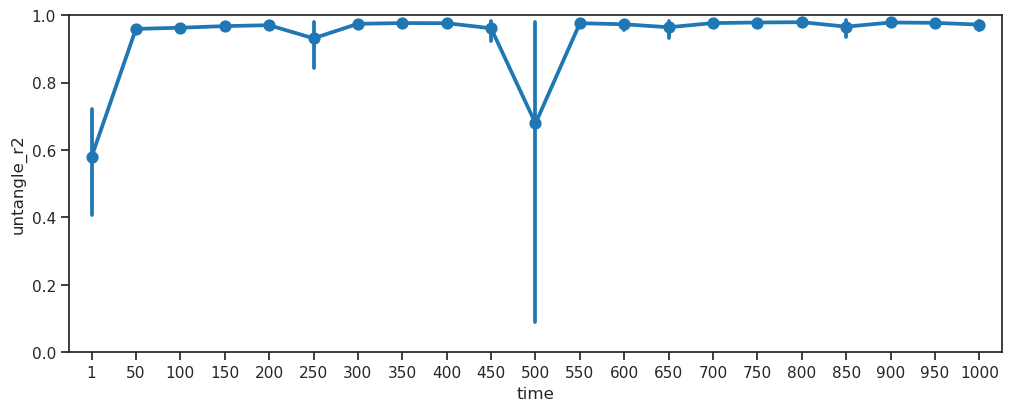

In [24]:
fig, ax = create_figure(1, 1, (10, 4))
sns.pointplot(data=df2p, x='time', y='untangle_r2', ax=ax)
ax.set(ylim=(0, 1))

[(0.0, 1.0)]

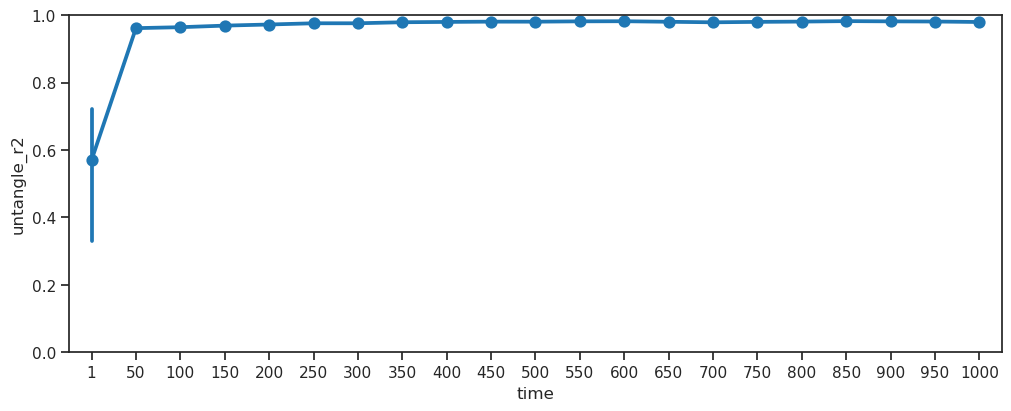

In [46]:
df2p.loc[df2p['time'] == 1000]

,n_latents,lr,seed,split,time,untangle_r2,untangle_r2_a,untangle_r2_b,untangle_corr,untangle_corr_a,untangle_corr_b,recon_r2,recon_mse,recon_mse_perdim,%-zeros
41,96,0.0001,400,tst,1000,NaN,-9.780324e-01,2.975790e-01,0.685484,0.583143,0.787825,0.955343,10.193288,2.488596,0.779922
83,96,0.0001,401,tst,1000,NaN,-2.325926e+01,-3.467433e+01,0.059774,0.142306,-0.022758,0.959751,9.186735,2.242855,0.807300
125,96,0.0001,402,tst,1000,NaN,-8.092272e+02,-4.000351e+03,0.009157,0.026671,-0.008356,0.963039,8.417047,2.054943,0.788847
167,96,0.0005,400,tst,1000,NaN,-2.651229e+00,-1.823062e+00,0.481357,0.461644,0.501070,-5.692808,1325.621338,323.638022,0.778531
209,96,0.0005,401,tst,1000,0.983785,9.816257e-01,9.859446e-01,0.992887,0.992553,0.993222,0.989644,2.357203,0.575489,0.788576
251,96,0.0005,402,tst,1000,NaN,-5.489239e+01,-1.249926e+02,0.122357,0.150212,0.094501,-92.064240,19475.791016,4754.831791,0.796693
293,128,0.0001,400,tst,1000,NaN,-1.550873e+02,-2.728924e+02,-0.101211,-0.343873,0.141450,0.965077,7.971783,1.946236,0.840571
335,128,0.0001,401,tst,1000,NaN,-1.598891e+08,-1.430374e+07,-0.289985,-0.335079,-0.244892,0.967460,7.407117,1.808378,0.831157
377,128,0.0001,402,tst,1000,0.577127,8.300211e-01,3.242336e-01,0.891906,0.928970,0.854842,0.968322,7.226454,1.764271,0.839398
419,128,0.0005,400,tst,1000,0.973018,9.677550e-01,9.782815e-01,0.987272,0.985011,0.989534,0.990919,2.068567,0.505021,0.831291


In [44]:
untangle_r2 = df2p.loc[df2p['time'] == 1000, 'untangle_r2'].values
untangle_r2

array([       nan,        nan,        nan,        nan, 0.98378515,
              nan,        nan,        nan, 0.57712734, 0.9730182 ,
       0.8579731 ,        nan], dtype=float32)

(0.9801863638447066, 0.013222083775668659)

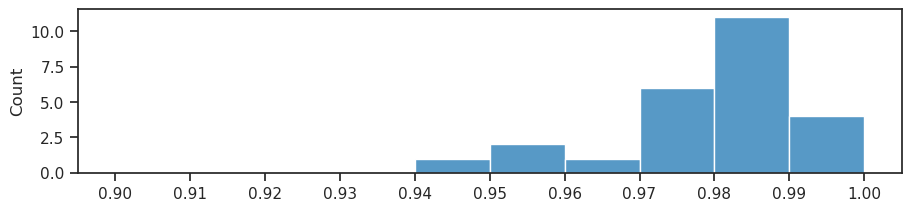

In [64]:
untangle_r2 = df2p.loc[df2p['time'] == 1000, 'untangle_r2'].values

fig, ax = create_figure(1, 1, (9, 2))
sns.histplot(untangle_r2, bins=np.linspace(0.90, 1.0, 11))
ax.locator_params(axis='x', nbins=20)

untangle_r2.mean(), untangle_r2.std()

In [ ]:
info_keys = [
    'dataset', 'type', 'latent_act', 'model_str',
    'seq_len', 'kl_beta', 'n_latents',
]

df = collections.defaultdict(list)
for f in tqdm(files):
    is_amortized = 'amort' in f
    try:
        load = np.load(
            pjoin(results_dir, f),
            allow_pickle=True,
        ).item()
    except EOFError:
        print(f"EOFError:\n{f}")
        continue

    info, results = load['info'], load['results']
    if isinstance(info['n_latents'], list):
        info['n_latents'] = info['n_latents'][0]

    # info
    for k in info_keys:
        df[k].append(info.get(k, None))
    df['amort'].append(is_amortized)

    # results
    vals = {
        # '%-zeros_vld': np.mean(results['results_xtract']['vld']['samples'][:, -1, :] == 0.0),
        # 'r2_recon_vld': results['results_xtract']['vld']['r2'][-1],
        # 'r2_untangle_vld': results['r2_zg']['vld'][1000].mean(),
        # 'r2_untangle_vld_0': results['r2_zg']['vld'][1000][0],
        # 'r2_untangle_vld_1': results['r2_zg']['vld'][1000][1],
        # 'r_untangle_vld': results['corr_zg']['vld'][1000].mean(),
        # 'r_untangle_vld_0': results['corr_zg']['vld'][1000][0],
        # 'r_untangle_vld_1': results['corr_zg']['vld'][1000][1],
        'r2_recon_tst': results['results_xtract']['tst']['r2'][-1],
        'r2_untangle_tst': results['r2_zg']['tst'][1000].mean(),
        'r_untangle_tst': results['corr_zg']['tst'][1000].mean(),
        '%-zeros_tst': np.mean(results['results_xtract']['tst']['samples'][:, -1, :] == 0.0),
        'r2_untangle_tst_0': results['r2_zg']['tst'][1000][0],
        'r2_untangle_tst_1': results['r2_zg']['tst'][1000][1],
        'r_untangle_tst_0': results['corr_zg']['tst'][1000][0],
        'r_untangle_tst_1': results['corr_zg']['tst'][1000][1],
    }
    for k, v in vals.items():
        df[k].append(v)
df = pd.DataFrame(df)
df.shape

In [6]:
_df = df.loc[
    (df['seq_len'] == 32) &
    (df['n_latents'] == 96) &
    (df['dataset'] == 'BALLS64')
]

In [8]:
_df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,r2_recon_tst,r2_untangle_tst,r_untangle_tst,%-zeros_tst,r2_untangle_tst_0,r2_untangle_tst_1,r_untangle_tst_0,r_untangle_tst_1
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.338011,-0.262225,0.668500,0.880439,-0.410636,-0.113815,0.642906,0.694093
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.966763,0.937432,0.985006,0.000000,0.904382,0.970483,0.980146,0.989865
204,BALLS64,poisson,None,poisson,32,24.0,96,False,0.994131,0.985870,0.994700,0.763405,0.981176,0.990563,0.993747,0.995653
206,BALLS64,poisson,None,poisson,32,48.0,96,False,0.993593,0.942868,0.991724,0.733747,0.982674,0.903062,0.994272,0.989177
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.993327,0.990167,0.995994,0.751850,0.988992,0.991342,0.995841,0.996147


In [6]:
columns_to_process = [
    'r2_recon_vld', 'r2_recon_tst',
    'r2_untangle_vld', 'r2_untangle_vld_0', 'r2_untangle_vld_1',
    'r2_untangle_tst', 'r2_untangle_tst_0', 'r2_untangle_tst_1',
]
for col in columns_to_process:
    df[col] = df[col].mask(df[col] < 0, np.nan)

df['avg_perf'] = (df['r2_untangle_tst'] + df['r2_recon_tst']) / 2

In [7]:
df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.874103,0.880439,0.513077,0.338011,0.873904,0.876920,0.870889,NaN,NaN,NaN,NaN
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.000000,0.000000,0.976597,0.966763,0.997010,0.997084,0.996937,0.937432,0.904382,0.970483,0.952098
2,BALLS16,poisson,None,poisson,8,4.0,8,False,0.179037,0.160960,0.722468,0.536938,0.941976,0.927955,0.955997,0.637630,0.536667,0.738592,0.587284
3,BALLS16,poisson,None,poisson,8,4.0,16,False,0.396294,0.448500,0.836406,0.844588,0.989995,0.991556,0.988433,0.937603,0.939815,0.935391,0.891095
4,BALLS16,poisson,None,poisson,8,4.0,24,False,0.590977,0.567368,0.910668,0.910017,0.994232,0.994898,0.993566,0.962905,0.967815,0.957995,0.936461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,BALLS64,poisson,None,poisson,32,64.0,64,False,0.649978,0.626374,0.991294,0.991112,0.998350,0.998530,0.998170,0.989804,0.990533,0.989074,0.990458
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747
210,BALLS64,poisson,None,poisson,8,8.0,32,False,0.630808,0.590924,0.969510,0.969814,0.997763,0.998181,0.997346,0.983284,0.986977,0.979591,0.976549
211,BALLS64,poisson,None,poisson,8,4.0,256,False,0.882506,0.869603,0.992897,NaN,0.997898,0.997961,0.997836,NaN,NaN,NaN,NaN


In [8]:
df['r2_untangle_tst'].max(), df['r2_recon_tst'].max()

(0.9901668550934274, 0.994131326675415)

In [9]:
df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.874103,0.880439,0.513077,0.338011,0.873904,0.876920,0.870889,NaN,NaN,NaN,NaN
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.000000,0.000000,0.976597,0.966763,0.997010,0.997084,0.996937,0.937432,0.904382,0.970483,0.952098
2,BALLS16,poisson,None,poisson,8,4.0,8,False,0.179037,0.160960,0.722468,0.536938,0.941976,0.927955,0.955997,0.637630,0.536667,0.738592,0.587284
3,BALLS16,poisson,None,poisson,8,4.0,16,False,0.396294,0.448500,0.836406,0.844588,0.989995,0.991556,0.988433,0.937603,0.939815,0.935391,0.891095
4,BALLS16,poisson,None,poisson,8,4.0,24,False,0.590977,0.567368,0.910668,0.910017,0.994232,0.994898,0.993566,0.962905,0.967815,0.957995,0.936461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,BALLS64,poisson,None,poisson,32,64.0,64,False,0.649978,0.626374,0.991294,0.991112,0.998350,0.998530,0.998170,0.989804,0.990533,0.989074,0.990458
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747
210,BALLS64,poisson,None,poisson,8,8.0,32,False,0.630808,0.590924,0.969510,0.969814,0.997763,0.998181,0.997346,0.983284,0.986977,0.979591,0.976549
211,BALLS64,poisson,None,poisson,8,4.0,256,False,0.882506,0.869603,0.992897,NaN,0.997898,0.997961,0.997836,NaN,NaN,NaN,NaN


<Axes: xlabel='n_latents', ylabel='r2_untangle_tst'>

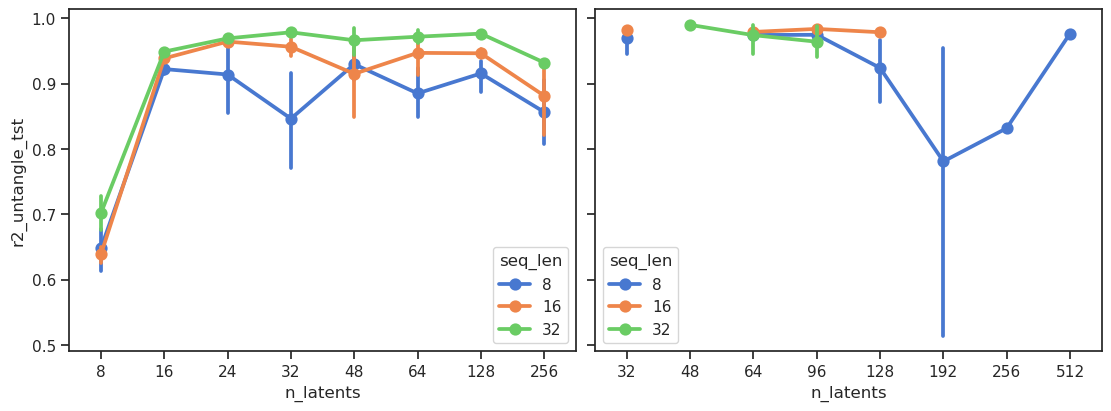

In [10]:
fig, axes = create_figure(1, 2, (11, 4), sharey='all')

_df = df.loc[df['dataset'] == 'BALLS16']
sns.pointplot(data=_df, x='n_latents', hue='seq_len', palette='muted', y='r2_untangle_tst', ax=axes[0])

_df = df.loc[df['dataset'] == 'BALLS64']
sns.pointplot(data=_df, x='n_latents', hue='seq_len', palette='muted', y='r2_untangle_tst', ax=axes[1])

#  ax.set(ylim=(0, 1))

In [13]:
_df = df.loc[df['dataset'] == 'BALLS64']

In [14]:
df.sort_values(by='avg_perf', ascending=False)[:20]

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747
208,BALLS64,poisson,None,poisson,32,64.0,64,False,0.649978,0.626374,0.991294,0.991112,0.998350,0.998530,0.998170,0.989804,0.990533,0.989074,0.990458
203,BALLS64,poisson,None,poisson,32,24.0,64,False,0.653123,0.664990,0.993813,0.992571,0.998423,0.998407,0.998440,0.987884,0.988625,0.987143,0.990227
204,BALLS64,poisson,None,poisson,32,24.0,96,False,0.742707,0.763405,0.995165,0.994131,0.998745,0.998719,0.998772,0.985870,0.981176,0.990563,0.990000
182,BALLS64,poisson,None,poisson,16,8.0,64,False,0.623729,0.619955,0.992346,0.991346,0.997785,0.997680,0.997890,0.986831,0.987326,0.986335,0.989088
188,BALLS64,poisson,None,poisson,16,16.0,96,False,0.766865,0.748902,0.992864,0.991853,0.997904,0.997823,0.997984,0.984894,0.983428,0.986359,0.988374
184,BALLS64,poisson,None,poisson,16,12.0,96,False,0.766661,0.756925,0.991910,0.991287,0.998218,0.998232,0.998204,0.984741,0.985825,0.983658,0.988014
207,BALLS64,poisson,None,poisson,32,64.0,48,False,0.635566,0.637222,0.987000,0.985912,0.998443,0.998121,0.998764,0.989842,0.989140,0.990543,0.987877
192,BALLS64,poisson,None,poisson,16,24.0,96,False,0.772927,0.776578,0.991924,0.990936,0.997784,0.997694,0.997873,0.983512,0.987287,0.979737,0.987224
183,BALLS64,poisson,None,poisson,16,12.0,64,False,0.660209,0.654875,0.991607,0.990487,0.997698,0.997644,0.997753,0.982977,0.980906,0.985048,0.986732


In [16]:
_df

,dataset,type,latent_act,model_str,seq_len,kl_beta,n_latents,amort,%-zeros_vld,%-zeros_tst,r2_recon_vld,r2_recon_tst,r2_untangle_vld,r2_untangle_vld_0,r2_untangle_vld_1,r2_untangle_tst,r2_untangle_tst_0,r2_untangle_tst_1,avg_perf
0,BALLS64,gaussian,relu,gaussian+relu,32,64.0,96,False,0.874103,0.880439,0.513077,0.338011,0.873904,0.876920,0.870889,NaN,NaN,NaN,NaN
1,BALLS64,gaussian,None,gaussian,32,64.0,96,False,0.000000,0.000000,0.976597,0.966763,0.997010,0.997084,0.996937,0.937432,0.904382,0.970483,0.952098
204,BALLS64,poisson,None,poisson,32,24.0,96,False,0.742707,0.763405,0.995165,0.994131,0.998745,0.998719,0.998772,0.985870,0.981176,0.990563,0.990000
206,BALLS64,poisson,None,poisson,32,48.0,96,False,0.726489,0.733747,0.994015,0.993593,0.998597,0.998548,0.998647,0.942868,0.982674,0.903062,0.968230
209,BALLS64,poisson,None,poisson,32,64.0,96,False,0.725450,0.751850,0.993546,0.993327,0.998713,0.998739,0.998687,0.990167,0.988992,0.991342,0.991747


In [ ]:
t-32_b-64_k-96